In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = '/content/Restaurant_Branch_Performance_Dataset.csv' # Update if your filename differs
df = pd.read_csv(file_path)

# Display basic information to ensure successful loading
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (350, 22)


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [3]:
# Handle missing values in 'Promotion'
df['Promotion'] = df['Promotion'].fillna('No Promotion')

# Verify no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [4]:
# Generate summary statistics for numerical variables
summary_stats = df.describe().T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']

print("--- Numerical Summary Statistics ---")
display(summary_stats[['mean', 'std', 'min', '50%', 'max', 'range']])

--- Numerical Summary Statistics ---


,mean,std,min,50%,max,range
Staff_Count,11.957143,4.338261,5.00,11.000,24.00,19.00
Marketing_Spend,5516.347743,2050.906967,725.35,5393.370,11784.96,11059.61
Customers,217.377143,56.722524,77.00,213.000,360.00,283.00
Orders,187.054286,50.558371,71.00,182.500,334.00,263.00
Average_Bill,388.906371,82.488196,180.00,383.485,623.28,443.28
Revenue,86831.799657,36644.453901,20540.76,79766.880,194018.92,173478.16
Food_Cost,31807.545114,13896.888942,7262.01,28861.325,75946.59,68684.58
Operating_Cost,56621.444486,18467.842215,20782.38,53723.025,111489.14,90706.76
Profit,30210.355171,19508.592192,-6924.68,26873.870,89096.19,96020.87
Avg_Delivery_Min,26.098857,4.388125,13.90,26.100,38.30,24.40


In [5]:
# Average performance metrics grouped by Region
region_analysis = df.groupby('Region')[['Revenue', 'Profit', 'Customers', 'Customer_Rating']].mean().round(2)
region_analysis = region_analysis.sort_values(by='Profit', ascending=False)

print("--- Average Performance by Region ---")
display(region_analysis)

--- Average Performance by Region ---


,Revenue,Profit,Customers,Customer_Rating
Region,,,,
South,88320.22,30690.57,218.93,4.45
North,86946.94,30625.96,217.65,4.48
West,84126.72,28720.86,214.30,4.49


In [6]:
# Average performance metrics grouped by Store Type
store_analysis = df.groupby('Store_Type')[['Revenue', 'Profit', 'Avg_Delivery_Min', 'Operating_Cost']].mean().round(2)
store_analysis = store_analysis.sort_values(by='Revenue', ascending=False)

print("--- Average Performance by Store Type ---")
display(store_analysis)

--- Average Performance by Store Type ---


,Revenue,Profit,Avg_Delivery_Min,Operating_Cost
Store_Type,,,,
Premium,152867.31,62890.24,26.40,89977.08
Standard,87268.67,30630.79,25.98,56637.88
Express,52327.16,12742.14,26.17,39585.03


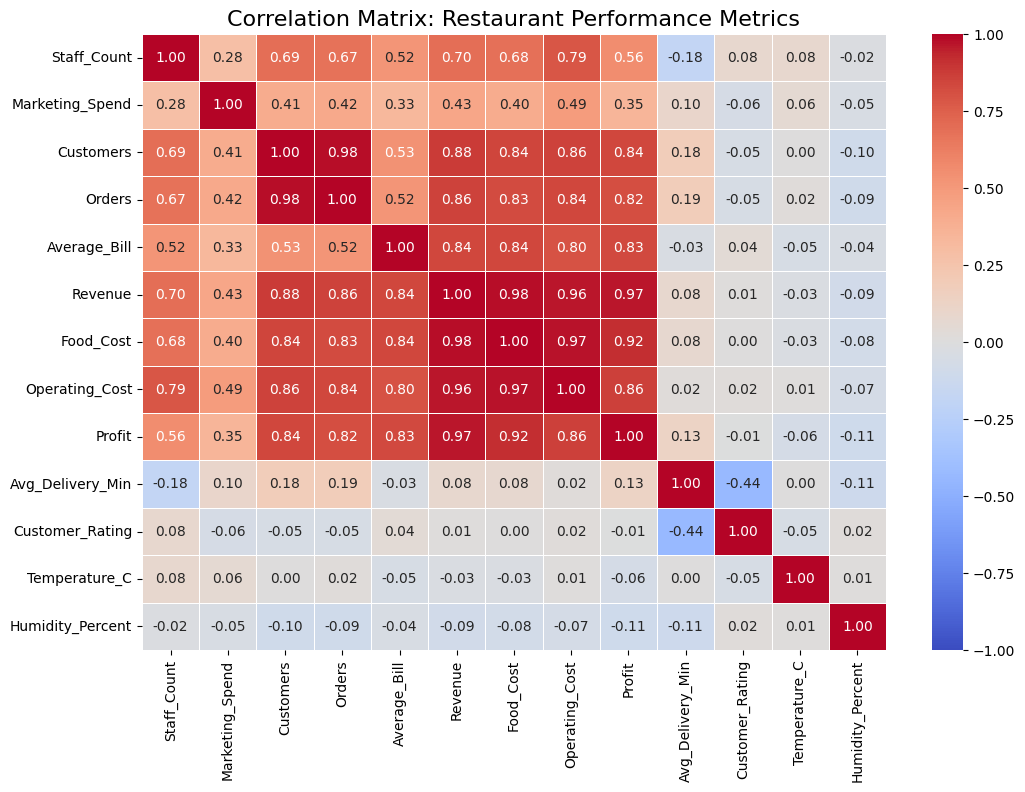


--- Top Factors Correlated with Profit ---
Revenue           0.966831
Food_Cost         0.917517
Operating_Cost    0.862061
Customers         0.835993
Average_Bill      0.828444
Name: Profit, dtype: float64


In [7]:
# Isolate numerical columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix: Restaurant Performance Metrics", fontsize=16)
plt.show()

# Display the highest correlations with Profit
print("\n--- Top Factors Correlated with Profit ---")
print(corr_matrix['Profit'].sort_values(ascending=False)[1:6])

### Exploratory Data Analysis (EDA) Summary

**1. Summary Statistics Analysis**
Looking at the overall numbers, the average daily revenue across all branches is roughly $86,831, leaving an average profit of $30,210. The restaurants are performing exceptionally well in customer satisfaction, with an average rating of 4.47 out of 5. The average delivery time is about 26 minutes.

**2. Regional Performance Analysis**
When comparing locations, all regions perform very similarly. The South region brings in the highest average revenue ($88,320), followed closely by the North ($86,946) and the West ($84,126). Because these numbers are so close, it shows that geography is not the main factor driving success.

**3. Store Type Analysis**
Unlike regions, the Store Type makes a massive difference in performance. "Premium" stores generate the highest average revenue ($152,867) and profit ($62,890). "Standard" stores sit in the middle, while "Express" stores bring in the lowest revenue ($52,327).

**4. Correlation Analysis**
The correlation heatmap shows us exactly what drives profit. The most important factors directly linked to higher profits are Total Revenue (0.96 correlation), Food Costs (0.91), and Number of Customers (0.83).

---

### 📝 Final Data-Driven Observations

1. **Premium Stores Make the Most Money:** "Premium" stores are the most profitable by far. They make about double the profit of "Standard" stores and almost five times as much as "Express" stores.
2. **More Customers = More Profit:** The data shows that the best way to increase profit is simply getting more customers in the door and increasing the average bill size.
3. **High Costs Mean Busy Days:** Having high food and operating costs isn't a bad thing in this dataset. Because it correlates heavily with profit, it just means the restaurant was extremely busy and made a lot of money that day.
4. **Consistency Across Regions:** There is no huge difference in sales based on location. The South region makes slightly more money, but the West region actually gets slightly better customer ratings (4.49).
5. **Some Days Lose Money:** Even though the average profits look great, the summary statistics show that the worst-performing day actually lost money (-$6,924). The company needs to figure out what went wrong on those specific days.
6. **Customers Are Very Happy:** Overall, people love the restaurants. The lowest rating anyone gave in the whole dataset was a 3.76, and delivery times remain highly consistent regardless of how busy the store gets.